---
date: "2026-07-28"
date-modified: last-modified
format:
  html:
    toc: true
---


# Autoregressive Models

## 1\. The Autoregressive Model (AR(p))

If the current return $r_t$ depends linearly on its past values, we can model it using an autoregressive process.

::: {#def-ar-p}
## Autoregressive Model of Order p: AR(p)
A time series $\{r_t\}$ is an AR(p) process if:
$$
r_t = \phi_0 + \phi_1 r_{t-1} + \phi_2 r_{t-2} + \dots + \phi_p r_{t-p} + a_t
$$
where $\{a_t\}$ is a [white noise](autocorrelation-and-stationarity.ipynb) series with mean zero and variance $\sigma_a^2$.
:::

### 1.1\. Properties of AR(1)

For the simplest case $p=1$, the model is $r_t = \phi_0 + \phi_1 r_{t-1} + a_t$. 
Assuming stationarity, we can find the unconditional mean:
$$
E[r_t] = \phi_0 + \phi_1 E[r_{t-1}] + E[a_t] \implies \mu = \phi_0 + \phi_1 \mu + 0 \implies \mu = \frac{\phi_0}{1 - \phi_1}
$$

The unconditional variance is:
$$
\text{Var}(r_t) = \phi_1^2 \text{Var}(r_{t-1}) + \text{Var}(a_t) \implies \gamma_0 = \phi_1^2 \gamma_0 + \sigma_a^2 \implies \gamma_0 = \frac{\sigma_a^2}{1 - \phi_1^2}
$$

The autocovariance at lag $\ell$ is $\gamma_\ell = \phi_1 \gamma_{\ell-1}$, which means the [autocorrelation function](autocorrelation-and-stationarity.ipynb) is:
$$
\rho_\ell = \phi_1 \rho_{\ell-1} = \phi_1^\ell
$$
This shows that the ACF of an AR(1) model **decays exponentially** to zero (it does not cut off).

## 2\. Stationarity of AR(p)

For a general AR(p) model to be stationary, we rewrite it using the backward shift operator $B$, where $B^k r_t = r_{t-k}$.

$$
(1 - \phi_1 B - \phi_2 B^2 - \dots - \phi_p B^p) r_t = \phi_0 + a_t
$$

::: {#thm-ar-stationarity}
## Stationarity Condition for AR(p)
The characteristic equation of the AR(p) model is:
$$
1 - \phi_1 x - \phi_2 x^2 - \dots - \phi_p x^p = 0
$$
The AR(p) process is weakly stationary if and only if all roots of this characteristic equation lie **outside the unit circle** in the complex plane (i.e., their absolute values are strictly greater than 1).
For AR(1), this reduces to $| \phi_1 | < 1$.
:::

## 3\. Identifying AR(p) Models

### 3.1\. Partial Autocorrelation Function (PACF)

Since the ACF of an AR(p) model decays slowly, we cannot use it to directly identify the order $p$. Instead, we use the Partial Autocorrelation Function (PACF).

::: {#def-pacf}
## Partial Autocorrelation Function (PACF)
The PACF at lag $\ell$ measures the marginal correlation between $r_t$ and $r_{t-\ell}$ after removing the linear effects of the intermediate variables $r_{t-1}, \dots, r_{t-\ell+1}$. 
For an AR(p) model, the PACF **cuts off** (becomes zero) after lag $p$.
:::

### 3.2\. Information Criteria

To formalize the selection of $p$, we balance model fit against model complexity using Information Criteria. 

::: {#def-aic-bic}
## Information Criteria (AIC and BIC)
The Akaike Information Criterion (AIC) is defined as:
$$
\text{AIC} = \frac{-2}{T} \ln(\text{Likelihood}) + \frac{2}{T} \times (\text{number of parameters})
$$
The Bayesian Information Criterion (BIC) applies a stronger penalty for the number of parameters. We choose the $p$ that minimizes these criteria.
:::

## 4\. Model Checking and Prediction

### 4.1\. Goodness of Fit

Once an AR(p) model is fitted, we can assess how well the model explains the variance of the data.
$$
R^2 = 1 - \frac{\text{RSS}}{\text{TSS}}
$$
where RSS is the residual sum of squares and TSS is the total sum of squares. An $R^2 > 70\%$ is considered excellent for many practical applications, but typical financial returns have much lower $R^2$ because predicting returns is difficult.

### 4.2\. Prediction

Given data up to time $T$, the 1-step ahead point forecast $\hat{r}_{T+1}$ is:
$$
\hat{r}_{T+1} = \phi_0 + \phi_1 r_T + \phi_2 r_{T-1} + \dots + \phi_p r_{T-p+1}
$$
Because the error $a_{T+1}$ has variance $\sigma_a^2$, the 95% prediction interval (assuming Gaussian errors) is approximately:
$$
\left[ \hat{r}_{T+1} \pm 2\sigma_a \right]
$$

::: {.callout-warning}
## Mean Reversion in AR(p) Prediction
As the forecast horizon $h$ increases, the point forecast $\hat{r}_{T+h}$ converges to the unconditional mean $\mu$. The prediction interval widens and converges to the unconditional variance.
:::



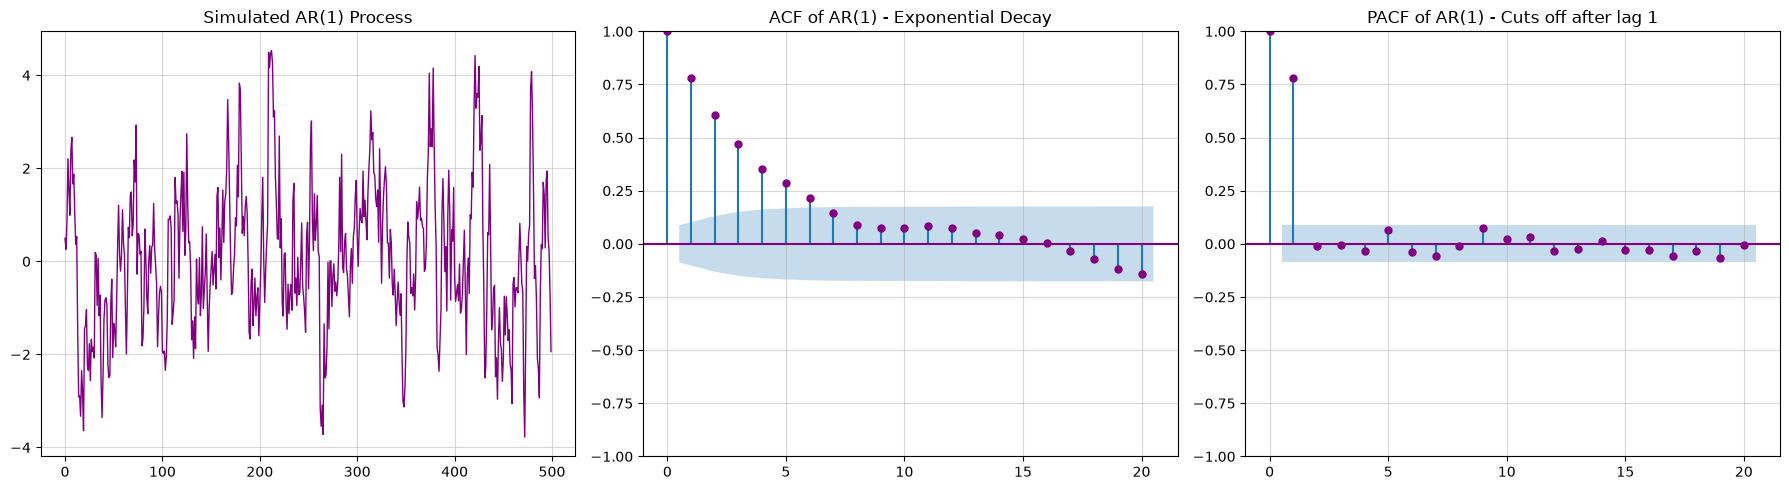

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

np.random.seed(42)

# Simulate AR(1) Process: r_t = 0.8 * r_{t-1} + a_t
# statsmodels AR uses negative signs for the characteristic equation: (1 - 0.8B)y_t = a_t
ar1 = ArmaProcess(ar=[1, -0.8], ma=[1])
y_ar1 = ar1.generate_sample(nsample=500)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(y_ar1, color='purple', linewidth=1)
axes[0].set_title("Simulated AR(1) Process")
axes[0].grid(True, alpha=0.5)

# ACF shows exponential decay
plot_acf(y_ar1, ax=axes[1], lags=20, color='purple')
axes[1].set_title("ACF of AR(1) - Exponential Decay")
axes[1].grid(True, alpha=0.5)

# PACF cuts off after lag 1
plot_pacf(y_ar1, ax=axes[2], lags=20, color='purple', method='ywm')
axes[2].set_title("PACF of AR(1) - Cuts off after lag 1")
axes[2].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()


> **References & Acknowledgments:**
> Notes adapted from *Analysis of Financial Time Series*, 2nd/3rd Edition by Ruey S. Tsay.
